**Exercise and Lab: Pulse Shape Discrimination**

The goal of this exercise is to perform a pulse shape analysis on real data.

A scintillation detector is exposed to both neutron and gamma radiation, both emitted from a source places some half meter away from the detector. A detected particle (neutron or gamma) will result in an electrical pulse (a short signal) from the detector. However, the pulse shape of the detector signal depends looks different for both types of particles.

Together with the detector pulse, the flight time of the particle from the source to the detector is measured. (More on this in the introductory video for the lab.) Since gammas move at speed of light and neutrons don't, the flight times provide a second way of discriminating between neutrons and gammas, independent of the pulse shapes. Use this information to label the data.

We start by downloading a data file. For testing there is a small data set, once everything works, there is more data...

In [51]:
# load data
# The code snippet below is responsible for downloading the dataset
# - for example when running via Google Colab.
# It is enough to load one of the files below.

# Small data file.
import os
if not os.path.exists("data_small.npy"):
  !gdown https://drive.google.com/uc?id=1Ejrt2O6rRj0N7F29pXxsa-gELsVaGhfA

# The small data file is enough to do this exercise but if you want you can also use much more data.
# Large data file. Uncomment this line only if you really want to use all data.
# !gdown https://drive.google.com/uc?id=1AcMxtW3GFsKpkLqDLwlDxgYFtbtzcrZQ

The next step will be do load the data into a numpy array and check it, e.g. by looking at some pulses.

The data consists of a (high) number of lines, each line representing one pulse.

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data_raw = np.load('data_small.npy')

# Check the size of the data file
print(data_raw.shape)
# Print the first pulse
# print(data_raw[0])

(55686, 514)


The first number in each line is a detector identifier, which we can happily ignore here.

The second number is the flight time in nanoseconds, this provides information about the particle type, neutron or gamma.

The pulse is sampled at a rate of 1 GHz, so the remaining 512 numbers represent 512 ns of the pulse shape.

(55686, 512)


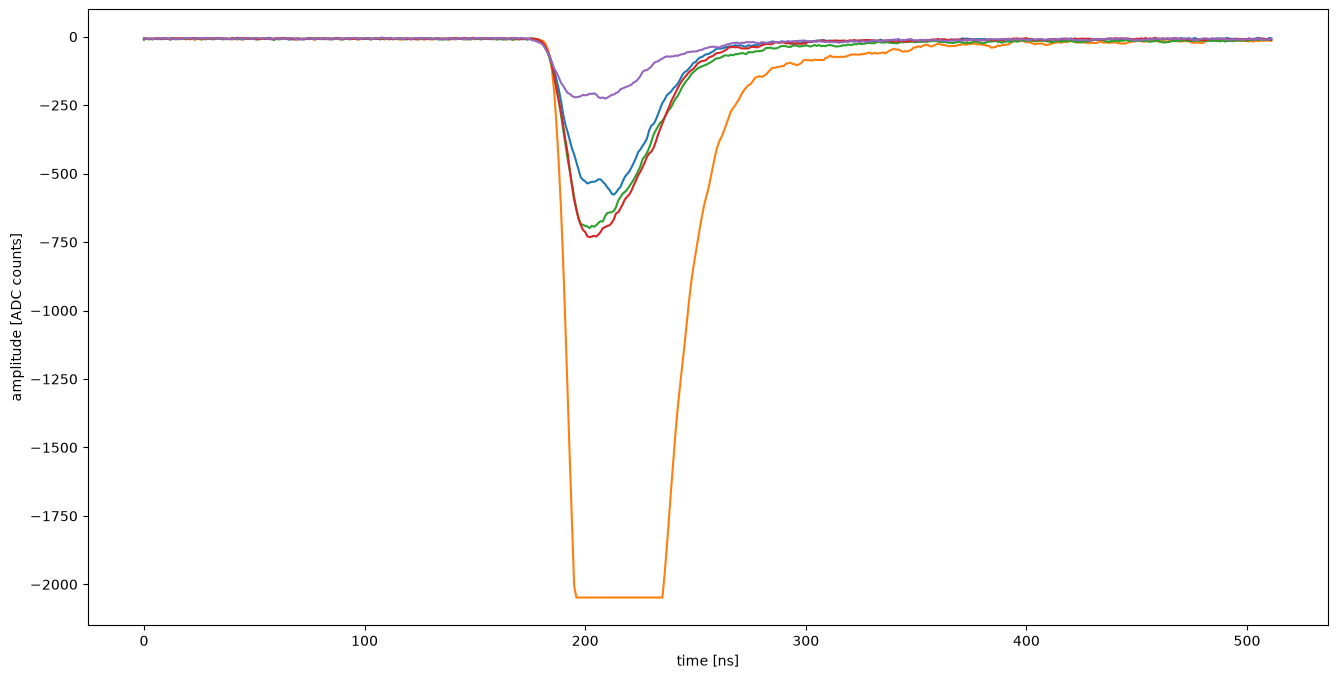

In [53]:
# Select only the pulse shape part of the data
pulses = data_raw[:,2:]
# Prepare a figure and plot some pulses
print(pulses.shape)
fig, ax = plt.subplots(figsize=(16,8))
ax.plot(pulses[0])
ax.plot(pulses[10])
ax.plot(pulses[100])
ax.plot(pulses[1000])
ax.plot(pulses[10000])
ax.set_xlabel("time [ns]")
ax.set_ylabel("amplitude [ADC counts]")
plt.show()

We will now extract the flight times.

In [54]:
times = data_raw[:,1]
print('Flight times between', times.min(), 'and', times.max(), 'nanoseconds.')

Flight times between -371.822 and 287.852 nanoseconds.


Negative flight times (also called times of flight, tof) are okay (for random coincidences), but we will restrict their range before plotting:

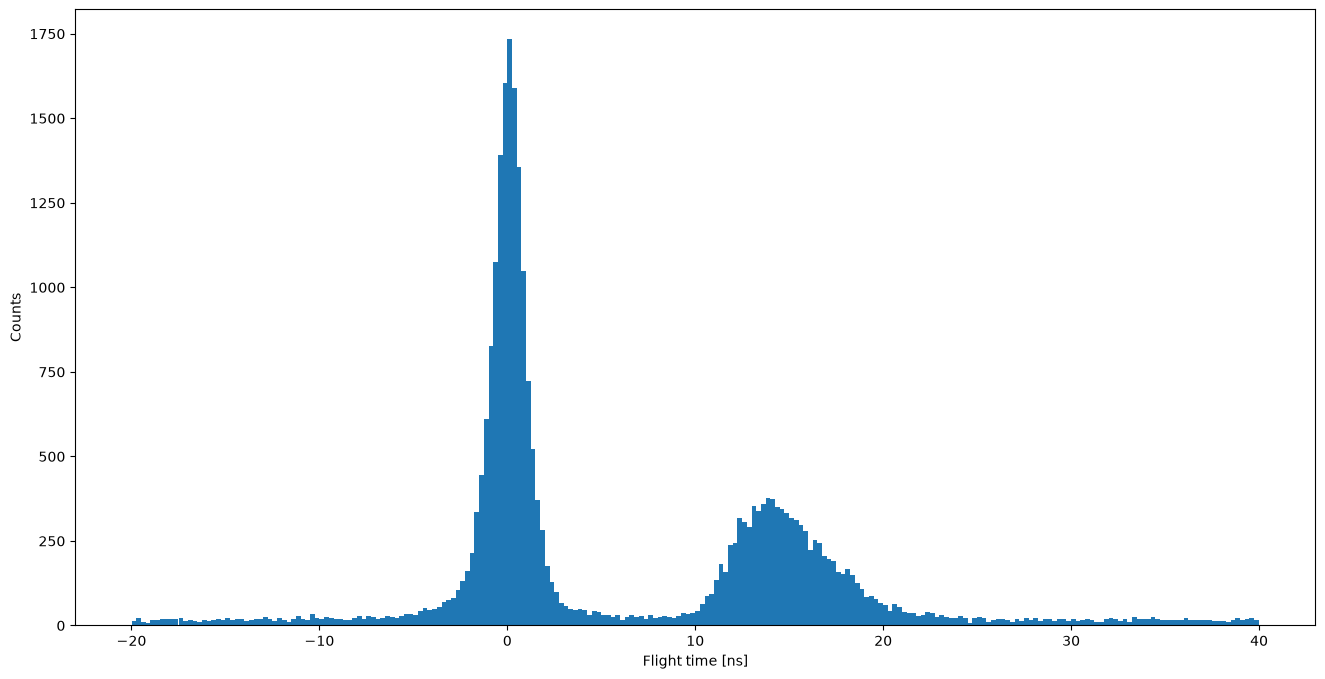

In [55]:
min_tof = -20
max_tof = 40
times = times[(times>=min_tof) & (times<=max_tof)]
# Now create a figure
fig, ax  = plt.subplots(figsize=(16,8))
ax.hist(times, bins=240)   # high resolution: 4 bins per nanosecond
ax.set_xlabel('Flight time [ns]')
ax.set_ylabel('Counts')
plt.show()

The flight time spectrum shows a gamma peak at around 0 ns and a neutron peak at around 10 to 20 ns.
You can now define flight time ranges within which you will accept gammas and neutrons. Please adjust the numbers below according to your data and your liking.
During the exercise class, we will discuss how the choice of the limits affects your results.

In [56]:
gamma_min_tof = -5
gamma_max_tof = 5
neutron_min_tof = 6
neutron_max_tof = 21

gammadata = data_raw[(data_raw[:,1] >= gamma_min_tof) & (data_raw[:,1] <= gamma_max_tof)]
gammapulses = gammadata[:,2:]
print('Gammas:  ', gammapulses.shape)

neutrondata = data_raw[(data_raw[:,1] >= neutron_min_tof) & (data_raw[:,1] <= neutron_max_tof)]
neutronpulses = neutrondata[:,2:]
print('Neutrons:', neutronpulses.shape)



Gammas:   (15870, 512)
Neutrons: (9339, 512)


You now have two arrays with pulse shapes, one with only gammas (according to the flight times) and one with only neutrons (again, according to the flight times). Each array contains a large number of pulse shapes, each pulse consists of 512 detector readings.

Let's start preparing the data for the training of a neural network.



In [ ]:
# make a combined data set containing both pulse types
data = np.vstack((gammapulses, neutronpulses))
labels = np.zeros(len(data), dtype=int)
labels[:len(gammapulses)] = 1
# gammas are labelled as 1, and neutrons are labelled as 0

# normalize the data per pulse to the maximum value of each pulse
data_positive = data * -1.0

baseline = np.mean(data_positive[:, :50], axis=1, keepdims=True)
data_baseline_corrected = data_positive - baseline

data_clipped = np.clip(data_baseline_corrected, 0, None)

data = data_clipped / np.max(data_clipped, axis=1, keepdims=True)

# # --------- Improvement on the data preprocessing ---------

# target_peak_index = 200

# current_peak_index = np.argmax(data, axis=1)

# shifts = target_peak_index - current_peak_index

# aligned_data = np.zeros_like(data)
# for i in range(len(data)):
#     aligned_data[i] = np.roll(data[i], shifts[i])

# data = aligned_data

# # ------------------------

samples_per_pulse = len(data[0])

# in case you use a CNN architecture, we need to add an empty axis.
data = data[:,:, np.newaxis]

# before we split up the dataset into training, validation and test data set, we need to shuffle the events
# otherwise we end up having only one type of event in our validation and test data sets.
np.random.seed(1234)
shuffle_indices = np.arange(0, len(data), dtype=int)
np.random.shuffle(shuffle_indices)
data = data[shuffle_indices]
labels = labels[shuffle_indices]

# split into training, validation and test data set
train_split = 0.7
val_split = 0.15
test_split = 0.15

train_size = int(len(data) * train_split)
val_size = int(len(data) * val_split)
test_size = int(len(data) * test_split)

data_train = data[:train_size]
labels_train = labels[:train_size]

data_val = data[train_size:train_size + val_size]
labels_val = labels[train_size:train_size + val_size]

data_test = data[train_size + val_size:]
labels_test = labels[train_size + val_size:]

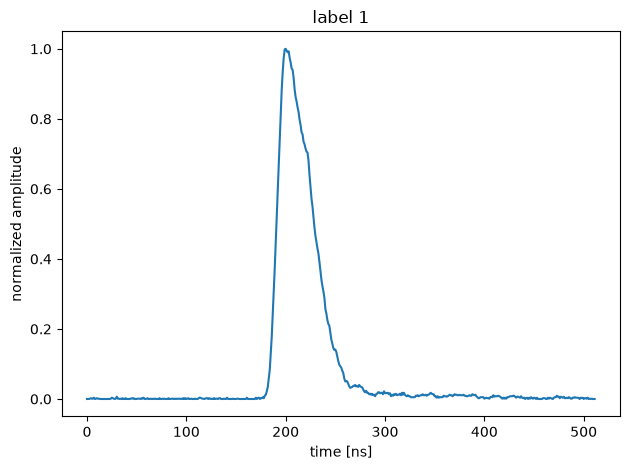

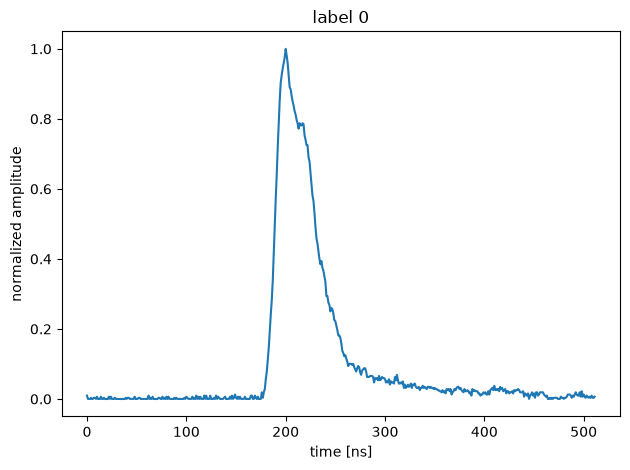

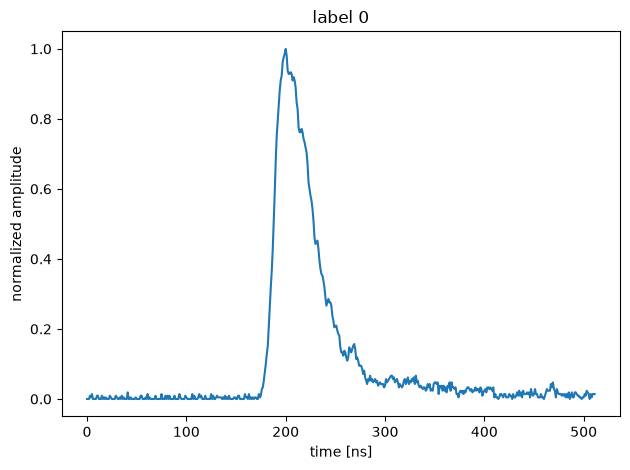

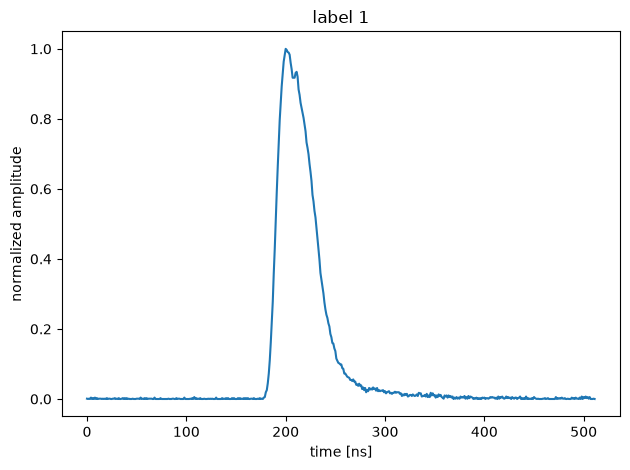

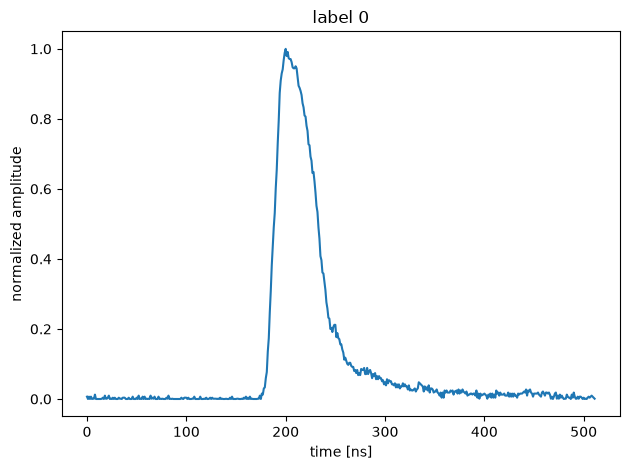

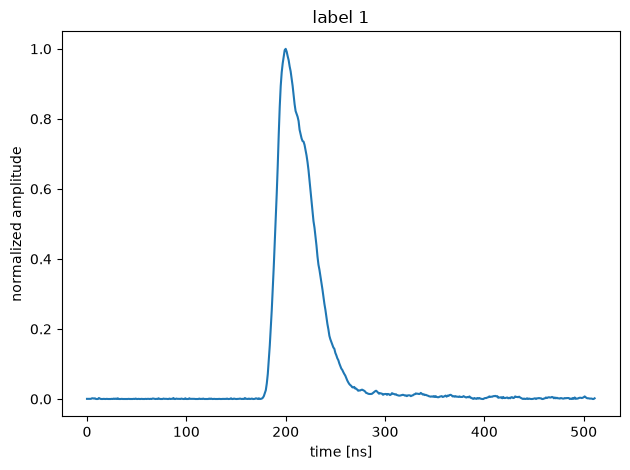

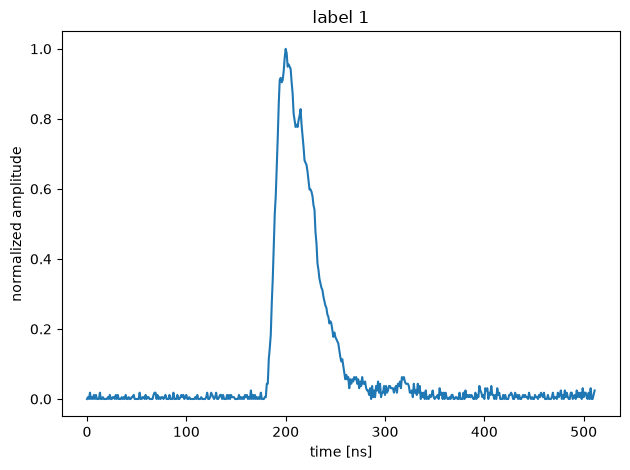

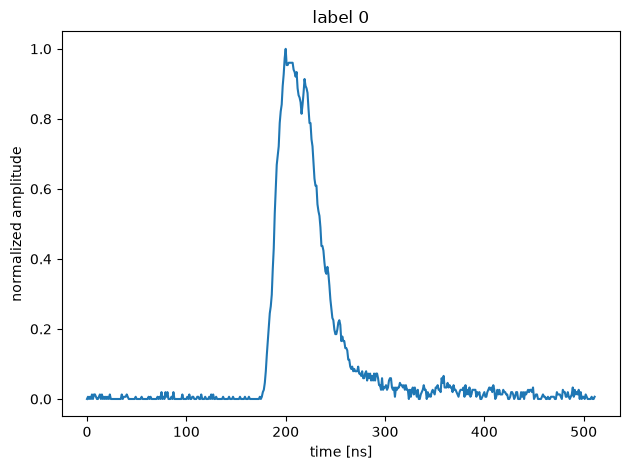

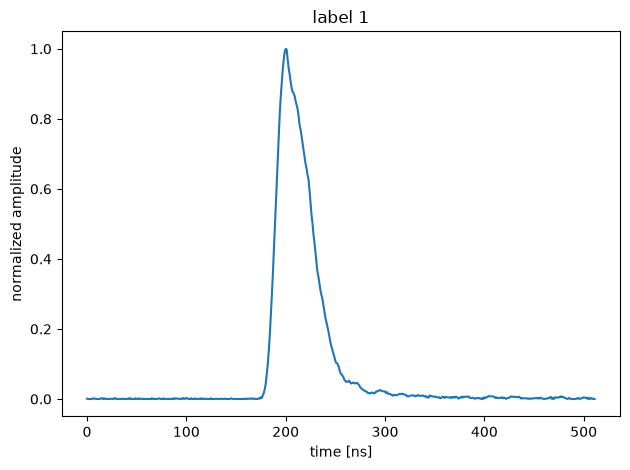

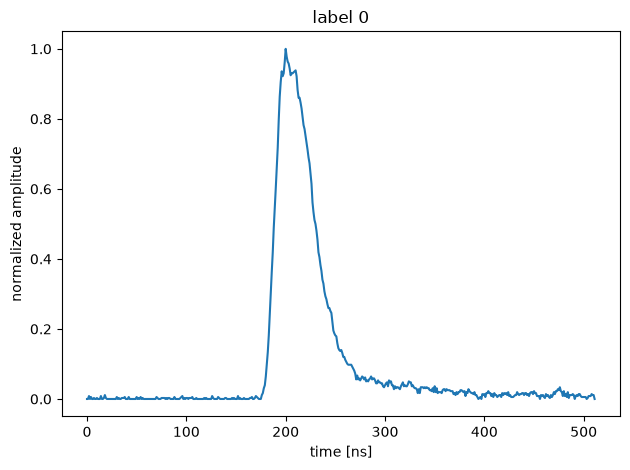

In [58]:
# plot a few events
for i in range(10):
    fig, ax = plt.subplots(1, 1)
    ax.plot(data_train[i,:,0])
    ax.set_title(f"label {labels_train[i]}")
    ax.set_xlabel("time [ns]")
    ax.set_ylabel("normalized amplitude")
    fig.tight_layout()
    plt.show()
    plt.close("all")

In [59]:
import os
path = os.path.join('saved_models')
if not os.path.exists(path):
    os.makedirs(path)

Now we can define the neural network and train it.

In [94]:
# first the usual imports
import platform
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Conv1D, Flatten, Dropout
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, AveragePooling1D, Input, Flatten, MaxPooling1D, GlobalAveragePooling1D, GlobalMaxPooling1D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import CSVLogger
import pickle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

In [61]:
if platform.system() == "Darwin":
    print("💻 macOS detected: Using Legacy Adam Optimizer")
    optimizer = keras.optimizers.legacy.Adam(learning_rate=1e-3)
else:
    print("🖥️ Desktop detected: Using Standard Adam Optimizer")
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)

💻 macOS detected: Using Legacy Adam Optimizer


In [62]:
model = Sequential(
    [
        keras.layers.Flatten(input_shape=(samples_per_pulse, 1)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(2, activation='softmax')
    ]
    , name='simple_dense_model'
)

print(model.summary())

# if you use a fully connected network (dense) you need to flatten the input data first. You can implement this
# as a network layer:
# model.add(Flatten(input_shape=(samples_per_pulse, 1)))

# if you use a convlutional layer first, you can directly use the input data
# model.add(Conv1D(, , padding=, activation=, input_shape=(samples_per_pulse, 1)))

Model: "simple_dense_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_8 (Flatten)         (None, 512)               0         
                                                                 
 dense_16 (Dense)            (None, 64)                32832     
                                                                 
 dense_17 (Dense)            (None, 2)                 130       
                                                                 
Total params: 32962 (128.76 KB)
Trainable params: 32962 (128.76 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [63]:
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    data_train, labels_train,
    validation_data=(data_val, labels_val),
    epochs=10,
    batch_size=32,
    callbacks=[
        ModelCheckpoint(filepath=os.path.join(path, 'simple_dense.h5'), save_best_only=True, monitor='val_loss'),
        CSVLogger(os.path.join(path, 'training_simple_dense.log'), append=False)
    ]
)

Epoch 1/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2510 - accuracy: 0.9319 - val_loss: 0.2107 - val_accuracy: 0.9484
Epoch 2/10
 39/552 [=>............................] - ETA: 2s - loss: 0.1786 - accuracy: 0.9567

/Users/frederikzielke/miniforge3/envs/tf-keras/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


552/552 [==============================] - 2s 4ms/step - loss: 0.1979 - accuracy: 0.9530 - val_loss: 0.2065 - val_accuracy: 0.9484
Epoch 3/10
552/552 [==============================] - 2s 4ms/step - loss: 0.1958 - accuracy: 0.9535 - val_loss: 0.2072 - val_accuracy: 0.9492
Epoch 4/10
552/552 [==============================] - 2s 4ms/step - loss: 0.1964 - accuracy: 0.9534 - val_loss: 0.2055 - val_accuracy: 0.9484
Epoch 5/10
552/552 [==============================] - 2s 4ms/step - loss: 0.1942 - accuracy: 0.9539 - val_loss: 0.2059 - val_accuracy: 0.9490
Epoch 6/10
552/552 [==============================] - 2s 3ms/step - loss: 0.1936 - accuracy: 0.9536 - val_loss: 0.2181 - val_accuracy: 0.9484
Epoch 7/10
552/552 [==============================] - 2s 3ms/step - loss: 0.1938 - accuracy: 0.9538 - val_loss: 0.2077 - val_accuracy: 0.9492
Epoch 8/10
552/552 [==============================] - 2s 3ms/step - loss: 0.1940 - accuracy: 0.9539 - val_loss: 0.2060 - val_accuracy: 0.9490
Epoch 9/10
552/55

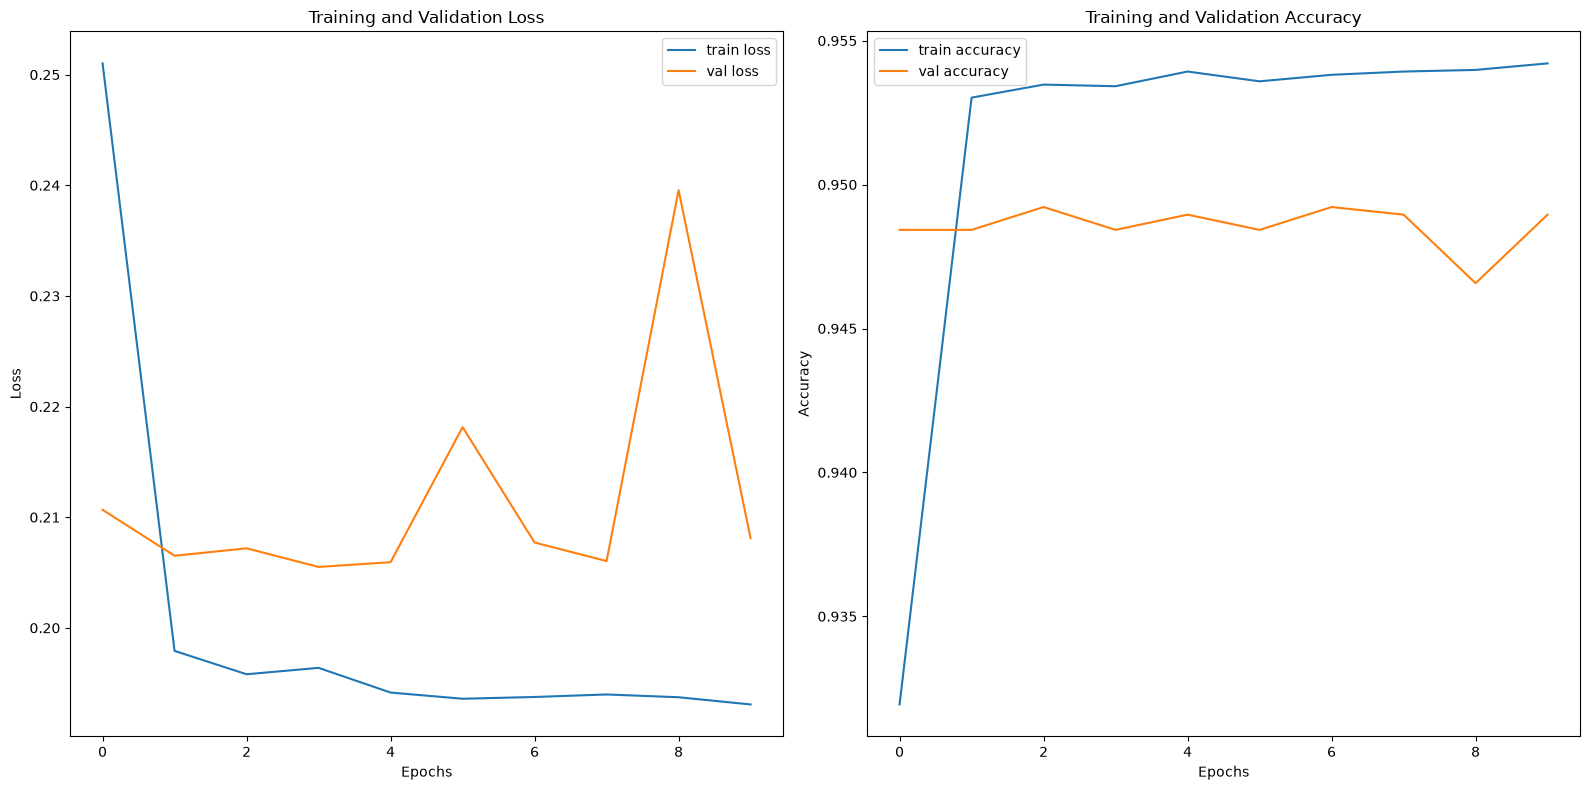

In [64]:
history = pd.read_csv(os.path.join(path, 'training_simple_dense.log'))


plt.figure(figsize=(16, 8))

# Loss Subplot
plt.subplot(1, 2, 1)

plt.plot(history['epoch'], history['loss'], label='train loss')
plt.plot(history['epoch'], history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy Subplot
plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['accuracy'], label='train accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

119/119 [==============================] - 0s 1ms/step


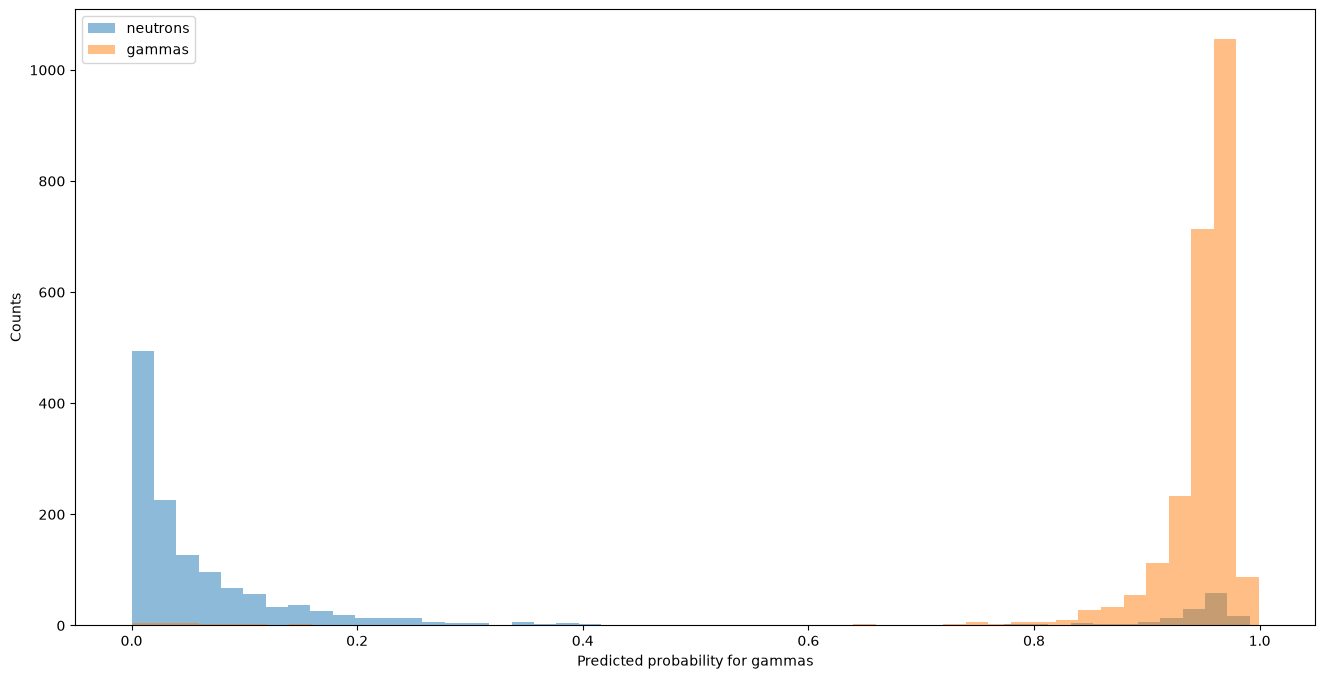

In [65]:
# plot a histogram of the predictions on the test data set
predictions = model.predict(data_test)

plt.figure(figsize=(16,8))
plt.hist(predictions[labels_test==0, 1], bins=50, alpha=0.5, label='neutrons')
plt.hist(predictions[labels_test==1, 1], bins=50, alpha=0.5, label='gammas')
plt.xlabel('Predicted probability for gammas')
plt.ylabel('Counts')
plt.legend()

This is already a solid start for such a simple network. It is highly confident in gamma classificatino and at least mostly confident in the neutron classification. A small number of neutrons get classified as gamma and a tiny number of gammas get classified as neutrons.

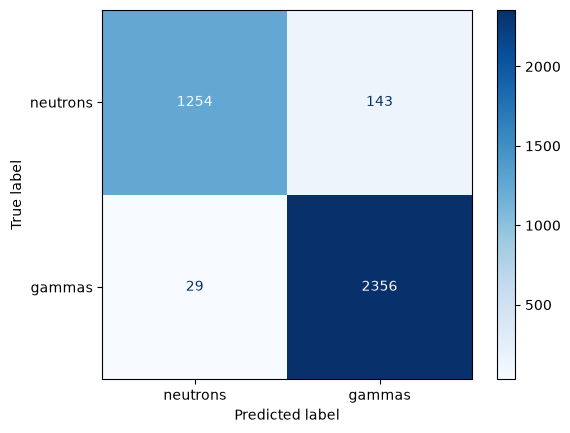

In [66]:
# plot confusion matrix
y_pred = np.argmax(predictions, axis=1)
cm = confusion_matrix(labels_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['neutrons', 'gammas'])
disp.plot(cmap=plt.cm.Blues)

In [67]:
model_2 = Sequential(
    [
        keras.layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=(samples_per_pulse, 1)),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(64, kernel_size=5, activation='relu'),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(2, activation='softmax')
    ]
    , name='simple_cnn_model'
)

print(model_2.summary())

Model: "simple_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_12 (Conv1D)          (None, 508, 32)           192       
                                                                 
 max_pooling1d_4 (MaxPoolin  (None, 254, 32)           0         
 g1D)                                                            
                                                                 
 conv1d_13 (Conv1D)          (None, 250, 64)           10304     
                                                                 
 max_pooling1d_5 (MaxPoolin  (None, 125, 64)           0         
 g1D)                                                            
                                                                 
 flatten_9 (Flatten)         (None, 8000)              0         
                                                                 
 dense_18 (Dense)            (None, 64)           

In [68]:
model_2.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.fit(
    data_train, labels_train,
    validation_data=(data_val, labels_val),
    epochs=10,
    batch_size=32,
    callbacks=[
        ModelCheckpoint(filepath=os.path.join(path, 'simple_cnn.h5'), save_best_only=True, monitor='val_loss'),
        CSVLogger(os.path.join(path, 'training_simple_cnn.log'), append=False)
    ]
)

Epoch 1/10
552/552 [==============================] - 3s 6ms/step - loss: 0.2244 - accuracy: 0.9399 - val_loss: 0.2063 - val_accuracy: 0.9482
Epoch 2/10
 34/552 [>.............................] - ETA: 2s - loss: 0.1652 - accuracy: 0.9632

/Users/frederikzielke/miniforge3/envs/tf-keras/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


552/552 [==============================] - 3s 5ms/step - loss: 0.1963 - accuracy: 0.9536 - val_loss: 0.2115 - val_accuracy: 0.9482
Epoch 3/10
552/552 [==============================] - 3s 6ms/step - loss: 0.1967 - accuracy: 0.9531 - val_loss: 0.2050 - val_accuracy: 0.9484
Epoch 4/10
552/552 [==============================] - 3s 6ms/step - loss: 0.1960 - accuracy: 0.9529 - val_loss: 0.2071 - val_accuracy: 0.9487
Epoch 5/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2007 - accuracy: 0.9523 - val_loss: 0.2172 - val_accuracy: 0.9484
Epoch 6/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2260 - accuracy: 0.9451 - val_loss: 0.2263 - val_accuracy: 0.9460
Epoch 7/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2285 - accuracy: 0.9471 - val_loss: 0.2331 - val_accuracy: 0.9450
Epoch 8/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2572 - accuracy: 0.9446 - val_loss: 0.2619 - val_accuracy: 0.9503
Epoch 9/10
552/55

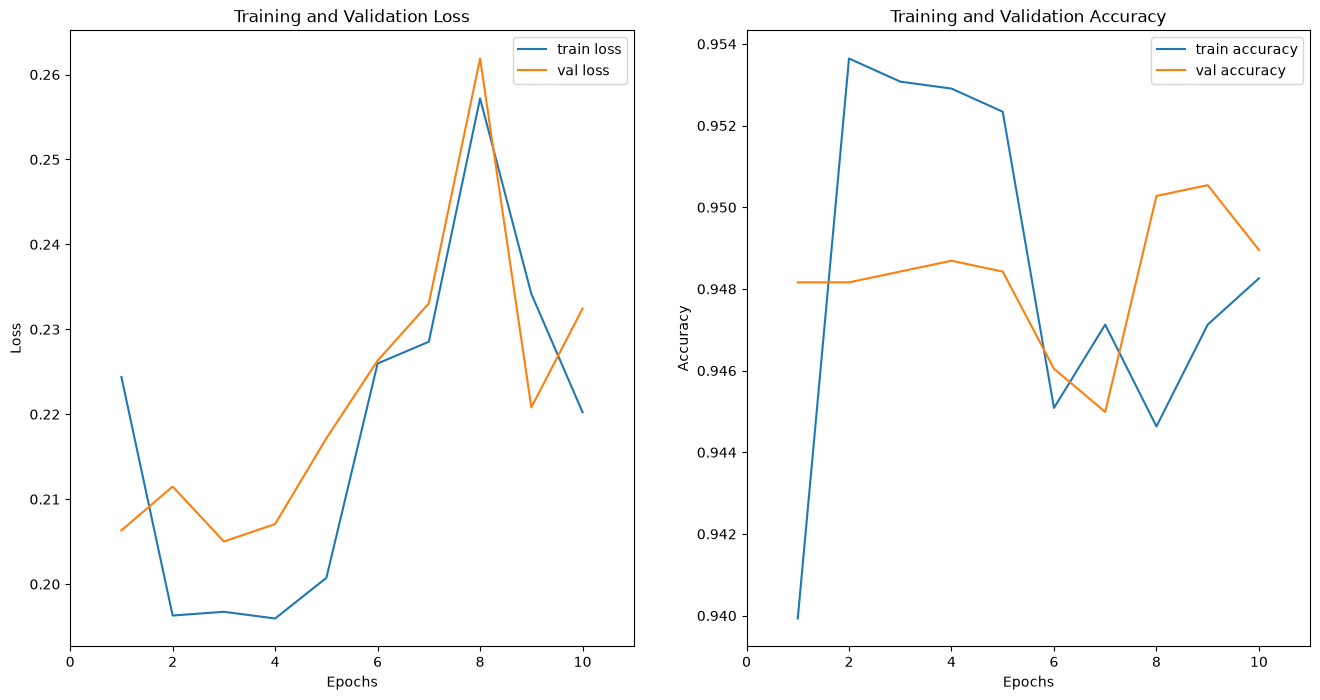

In [69]:
# plot the training and validation loss and accuracy
history_2 = pd.read_csv(os.path.join(path, 'training_simple_cnn.log'))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(history_2['epoch'] + 1, history_2['loss'], label='train loss')
plt.plot(history_2['epoch'] + 1, history_2['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.xlim(0, len(history_2['epoch']) + 1)
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2['epoch'] + 1, history_2['accuracy'], label='train accuracy')
plt.plot(history_2['epoch'] + 1, history_2['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.xlim(0, len(history_2['epoch']) + 1)
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

119/119 [==============================] - 0s 2ms/step


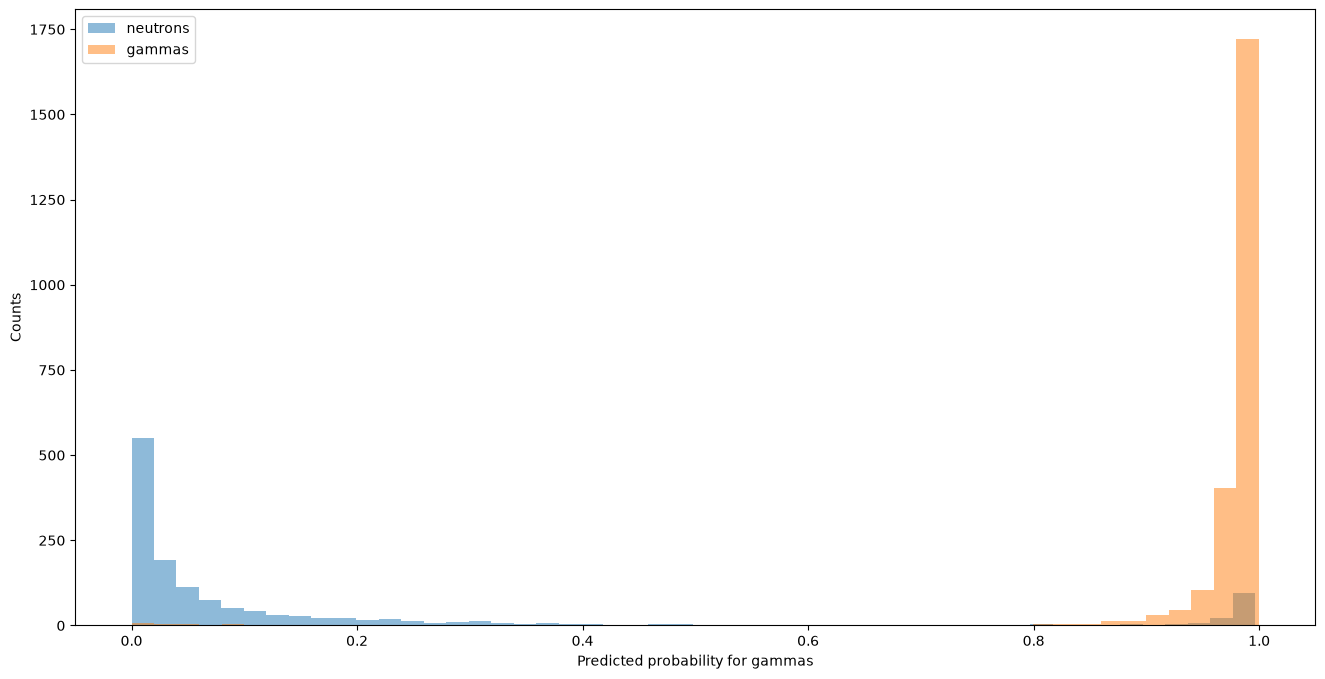

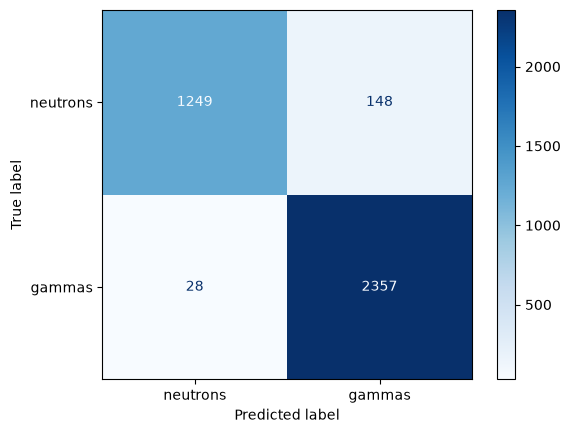

In [70]:
# plot histogram of the predictions on the test data set
predictions_2 = model_2.predict(data_test)

plt.figure(figsize=(16,8))
plt.hist(predictions_2[labels_test==0, 1], bins=50, alpha=0.5, label='neutrons')
plt.hist(predictions_2[labels_test==1, 1], bins=50, alpha=0.5, label='gammas')
plt.xlabel('Predicted probability for gammas')
plt.ylabel('Counts')
plt.legend()
plt.show()

# plot confusion matrix
y_pred_2 = np.argmax(predictions_2, axis=1)
cm_2 = confusion_matrix(labels_test, y_pred_2)
disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=['neutrons', 'gammas'])
disp_2.plot(cmap=plt.cm.Blues)

The network performs very similar to the simpler one. The confusion matrix basically has the same values. Judging by the distribution, the network is more confident in its classifications. Overall there is no real performance gain with the bigger network.

In [78]:
model_3 = Sequential(
    [
    Conv1D(32, kernel_size=15, activation='relu', input_shape=(samples_per_pulse, 1)),
    Dropout(0.1),
    AveragePooling1D(pool_size=2),
    Conv1D(64, kernel_size=5, activation='relu'),
    Dropout(0.1),
    AveragePooling1D(pool_size=2),
    Flatten(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
    ]
)

print(model_3.summary())

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_16 (Conv1D)          (None, 498, 32)           512       
                                                                 
 dropout_15 (Dropout)        (None, 498, 32)           0         
                                                                 
 average_pooling1d_6 (Avera  (None, 249, 32)           0         
 gePooling1D)                                                    
                                                                 
 conv1d_17 (Conv1D)          (None, 245, 64)           10304     
                                                                 
 dropout_16 (Dropout)        (None, 245, 64)           0         
                                                                 
 average_pooling1d_7 (Avera  (None, 122, 64)           0         
 gePooling1D)                                         

In [72]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)

class_weights = {0: weights[0], 1: weights[1]}

print(f"Class weights: {class_weights}")


model_3.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_3.fit(
    data_train, labels_train,
    validation_data=(data_val, labels_val),
    epochs=10,
    batch_size=32,
    class_weight = class_weights,
    callbacks=[
        ModelCheckpoint(filepath=os.path.join(path, 'simple_cnn_dropout.h5'), save_best_only=True, monitor='val_loss'),
        CSVLogger(os.path.join(path, 'training_simple_cnn_dropout.log'), append=False)
    ]
)

Class weights: {0: 1.3517695725448138, 1: 0.7935066103066822}
Epoch 1/10
552/552 [==============================] - 4s 7ms/step - loss: 0.2416 - accuracy: 0.9406 - val_loss: 0.2083 - val_accuracy: 0.9490
Epoch 2/10
 28/552 [>.............................] - ETA: 3s - loss: 0.2148 - accuracy: 0.9542

/Users/frederikzielke/miniforge3/envs/tf-keras/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


552/552 [==============================] - 3s 6ms/step - loss: 0.2178 - accuracy: 0.9523 - val_loss: 0.2116 - val_accuracy: 0.9460
Epoch 3/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2168 - accuracy: 0.9524 - val_loss: 0.2063 - val_accuracy: 0.9492
Epoch 4/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2149 - accuracy: 0.9523 - val_loss: 0.1997 - val_accuracy: 0.9487
Epoch 5/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2211 - accuracy: 0.9522 - val_loss: 0.2211 - val_accuracy: 0.9460
Epoch 6/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2166 - accuracy: 0.9528 - val_loss: 0.2049 - val_accuracy: 0.9484
Epoch 7/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2248 - accuracy: 0.9515 - val_loss: 0.2266 - val_accuracy: 0.9455
Epoch 8/10
552/552 [==============================] - 3s 5ms/step - loss: 0.2223 - accuracy: 0.9522 - val_loss: 0.2171 - val_accuracy: 0.9476
Epoch 9/10
552/55

119/119 [==============================] - 0s 1ms/step


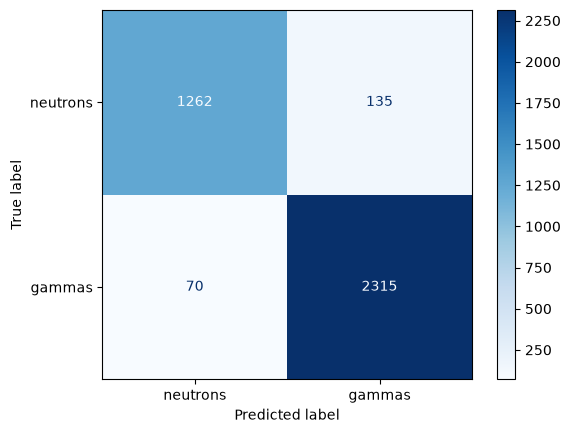

In [73]:
# plot confusion matrix
predictions_3 = model_3.predict(data_test)

cm_3 = confusion_matrix(labels_test, np.argmax(predictions_3, axis=1))

disp_3 = ConfusionMatrixDisplay(confusion_matrix=cm_3, display_labels=['neutrons', 'gammas'])
disp_3.plot(cmap=plt.cm.Blues)

In [99]:
# Trying another way of classifiying events more strictly and further preprocessing than before.


gamma_min_tof = -3
gamma_max_tof = 3
neutron_min_tof = 11
neutron_max_tof = 25

gammadata = data_raw[(data_raw[:,1] >= gamma_min_tof) & (data_raw[:,1] <= gamma_max_tof)]
gammapulses = gammadata[:,2:]
print('Gammas:  ', gammapulses.shape)

neutrondata = data_raw[(data_raw[:,1] >= neutron_min_tof) & (data_raw[:,1] <= neutron_max_tof)]
neutronpulses = neutrondata[:,2:]
print('Neutrons:', neutronpulses.shape)

# make a combined data set containing both pulse types
data = np.vstack((gammapulses, neutronpulses))
labels = np.zeros(len(data), dtype=int)
labels[:len(gammapulses)] = 1
# gammas are labelled as 1, and neutrons are labelled as 0

# normalize the data per pulse to the maximum value of each pulse
data_positive = data * -1.0

baseline = np.mean(data_positive[:, :50], axis=1, keepdims=True)
data_baseline_corrected = data_positive - baseline

data_clipped = np.clip(data_baseline_corrected, 0, None)

# --------- Low Energy Cut ---------
# It deteriorated the model performance
'''
pulse_energies = np.sum(data_clipped, axis=1)

# Plot the energy spectrum to visually identify the noise spike
plt.figure(figsize=(10, 6))
plt.hist(pulse_energies, bins=150, log=True) # Log scale makes the noise spike obvious
plt.xlabel('Pulse Energy (Integrated ADC counts)')
plt.ylabel('Counts')
plt.title('Energy Spectrum (Find the drop-off after the noise spike)')
plt.show()

# Define  threshold. 
# drop the lowest 5 percent of pulses.
threshold_value = np.percentile(pulse_energies, 5)
print(f"Calculated Energy Threshold (bottom 5%): {threshold_value:.2f}")

# Create a mask
valid_pulse_mask = pulse_energies > threshold_value

# Apply the mask to BOTH your data AND your labels
data_filtered = data_clipped[valid_pulse_mask]
labels_filtered = labels[valid_pulse_mask]

print(f"Original dataset size: {len(data_clipped)}")
print(f"Clean dataset size:  {len(data_filtered)}")
print(f"Dropped {len(data_clipped) - len(data_filtered)} low-energy pulses.")

data = data_filtered / np.max(data_filtered, axis=1, keepdims=True)
'''

data = data_clipped 
# --------- Improvement on the data preprocessing ---------

target_peak_index = 200

current_peak_index = np.argmax(data, axis=1)

shifts = target_peak_index - current_peak_index

aligned_data = np.zeros_like(data)
for i in range(len(data)):
    aligned_data[i] = np.roll(data[i], shifts[i])

# -------- calculate tail-to-total ratio ---------
tail_start = target_peak_index + 50  # Start of the tail region

# calculate total area
total_area = np.sum(aligned_data, axis=1)
total_area[total_area == 0] = 1  # Avoid division by zero

# calculate tail area
tail_area = np.sum(aligned_data[:, tail_start:], axis=1)

# calculate tail-to-total ratio
tail_to_total_ratio = tail_area / total_area

data = aligned_data / np.max(aligned_data, axis=1, keepdims=True)


samples_per_pulse = len(data[0])

# in case you use a CNN architecture, we need to add an empty axis.
data = data[:,:, np.newaxis]

# before we split up the dataset into training, validation and test data set, we need to shuffle the events
# otherwise we end up having only one type of event in our validation and test data sets.
np.random.seed(1234)
shuffle_indices = np.arange(0, len(data), dtype=int)
np.random.shuffle(shuffle_indices)
data = data[shuffle_indices]
labels = labels[shuffle_indices]
tail_to_total_ratio = tail_to_total_ratio[shuffle_indices]

# split into training, validation and test data set
train_split = 0.7
val_split = 0.15
test_split = 0.15

train_size = int(len(data) * train_split)
val_size = int(len(data) * val_split)
test_size = int(len(data) * test_split)

data_train = data[:train_size]
labels_train = labels[:train_size]

data_val = data[train_size:train_size + val_size]
labels_val = labels[train_size:train_size + val_size]

data_test = data[train_size + val_size:]
labels_test = labels[train_size + val_size:]

tail_to_total_train = tail_to_total_ratio[:train_size]
tail_to_total_val = tail_to_total_ratio[train_size:train_size + val_size]
tail_to_total_test = tail_to_total_ratio[train_size + val_size:]

Gammas:   (15089, 512)
Neutrons: (9068, 512)


In [91]:
model_3.compile(
    optimizer=keras.optimizers.legacy.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_3.fit(
    data_train, labels_train,
    validation_data=(data_val, labels_val),
    epochs=40,
    batch_size=32,
    callbacks=[
        ModelCheckpoint(filepath=os.path.join(path, 'simple_cnn_dropout_new_preprocessing.h5'), save_best_only=True, monitor='val_loss'),
        CSVLogger(os.path.join(path, 'training_simple_cnn_dropout_new_preprocessing.log'), append=False)
    ]
)

Epoch 1/40
529/529 [==============================] - 4s 6ms/step - loss: 0.1711 - accuracy: 0.9601 - val_loss: 0.1548 - val_accuracy: 0.9619
Epoch 2/40
 25/529 [>.............................] - ETA: 3s - loss: 0.1227 - accuracy: 0.9762

/Users/frederikzielke/miniforge3/envs/tf-keras/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


529/529 [==============================] - 3s 7ms/step - loss: 0.1690 - accuracy: 0.9608 - val_loss: 0.1837 - val_accuracy: 0.9597
Epoch 3/40
529/529 [==============================] - 3s 6ms/step - loss: 0.1701 - accuracy: 0.9611 - val_loss: 0.1545 - val_accuracy: 0.9619
Epoch 4/40
529/529 [==============================] - 3s 5ms/step - loss: 0.1667 - accuracy: 0.9608 - val_loss: 0.1537 - val_accuracy: 0.9622
Epoch 5/40
529/529 [==============================] - 3s 5ms/step - loss: 0.1678 - accuracy: 0.9611 - val_loss: 0.1541 - val_accuracy: 0.9622
Epoch 6/40
529/529 [==============================] - 3s 5ms/step - loss: 0.1727 - accuracy: 0.9608 - val_loss: 0.1554 - val_accuracy: 0.9622
Epoch 7/40
529/529 [==============================] - 3s 5ms/step - loss: 0.1676 - accuracy: 0.9617 - val_loss: 0.1532 - val_accuracy: 0.9625
Epoch 8/40
529/529 [==============================] - 3s 5ms/step - loss: 0.1694 - accuracy: 0.9610 - val_loss: 0.1704 - val_accuracy: 0.9616
Epoch 9/40
529/52

114/114 [==============================] - 0s 1ms/step


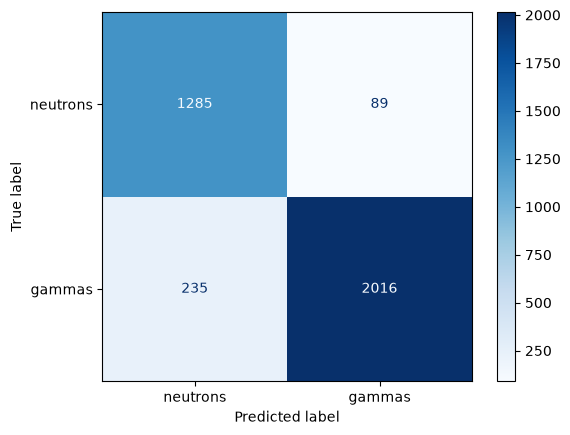

In [92]:
predictions_3 = model_3.predict(data_test)

cm_3 = confusion_matrix(labels_test, np.argmax(predictions_3, axis=1))

disp_3 = ConfusionMatrixDisplay(confusion_matrix=cm_3, display_labels=['neutrons', 'gammas'])
disp_3.plot(cmap=plt.cm.Blues)

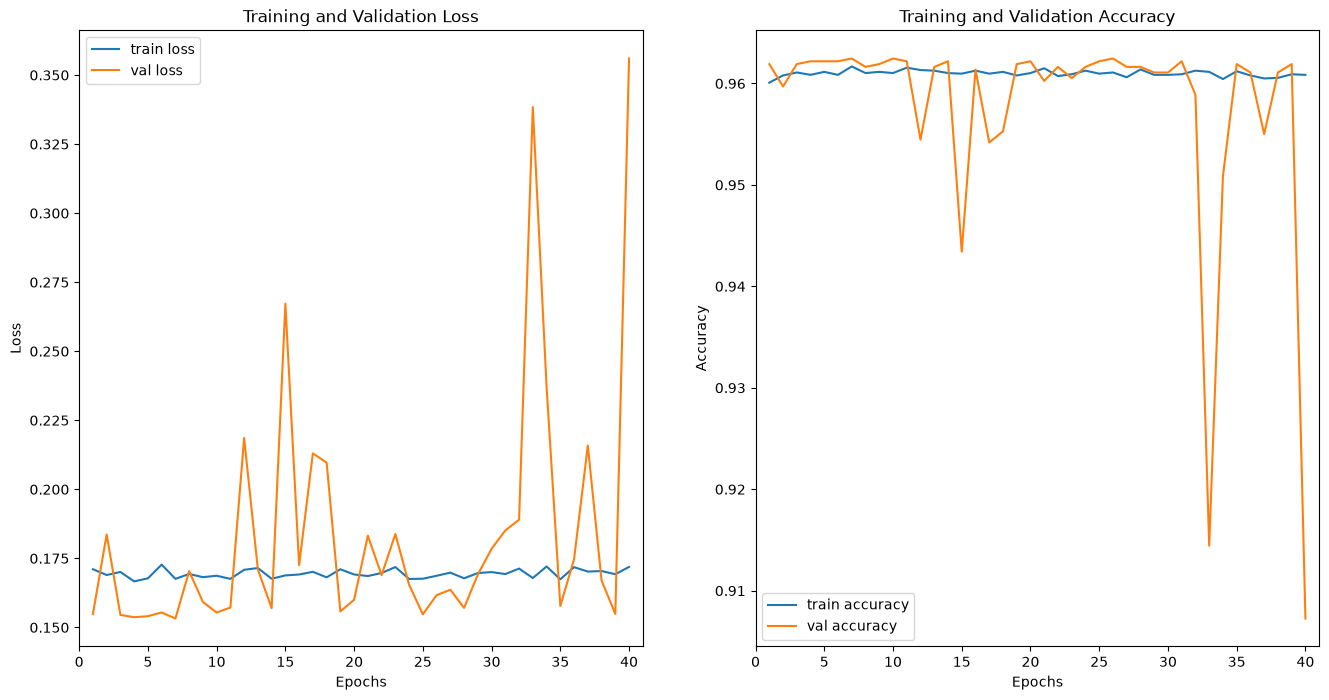

In [93]:
# plot loss and accuracy for the new preprocessing
history_3 = pd.read_csv(os.path.join(path, 'training_simple_cnn_dropout_new_preprocessing.log'))

plt.figure(figsize=(16, 8))
# Loss Subplot
plt.subplot(1, 2, 1)
plt.plot(history_3['epoch'] + 1, history_3['loss'], label='train loss')
plt.plot(history_3['epoch'] + 1, history_3['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.xlim(0, len(history_3['epoch']) + 1)
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy Subplot
plt.subplot(1, 2, 2)
plt.plot(history_3['epoch'] + 1, history_3['accuracy'], label='train accuracy')
plt.plot(history_3['epoch'] + 1, history_3['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.xlim(0, len(history_3['epoch']) + 1)
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

In [102]:
pulse_input = Input(shape=(samples_per_pulse, 1), name='waveform_input')

x = Conv1D(32, kernel_size=15, activation='relu')(pulse_input)
x = Dropout(0.1)(x)
x = AveragePooling1D(pool_size=2)(x)

x = Conv1D(64, kernel_size=5, activation='relu')(x)
x = Dropout(0.1)(x)
x = AveragePooling1D(pool_size=2)(x)

cnn_features = Flatten()(x)

# --- INPUT 2: The Engineered Physics Feature ---
physics_input = Input(shape=(1,), name='tail_to_total_input')

# --- CONCATENATION ---
merged_layer = concatenate([cnn_features, physics_input])

# --- FINAL DENSE CLASSIFICATION ---
y = Dropout(0.3)(merged_layer)
y = Dense(64, activation='relu')(y)
output = Dense(2, activation='softmax', name='classification_output')(y)

# --- BUILD THE MODEL ---
# Specify that this model takes a LIST of inputs
model_combined = Model(inputs=[pulse_input, physics_input], outputs=output, name='cnn_with_physics')

print(model_combined.summary())

Model: "cnn_with_physics"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 waveform_input (InputLayer  [(None, 512, 1)]             0         []                            
 )                                                                                                
                                                                                                  
 conv1d_20 (Conv1D)          (None, 498, 32)              512       ['waveform_input[0][0]']      
                                                                                                  
 dropout_21 (Dropout)        (None, 498, 32)              0         ['conv1d_20[0][0]']           
                                                                                                  
 average_pooling1d_10 (Aver  (None, 249, 32)              0         ['dropout_21[0]

In [103]:
model_combined.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_combined.fit(
    x=[data_train, tail_to_total_train], # Pass both inputs as a list
    y=labels_train,
    validation_data=([data_val, tail_to_total_val], labels_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        ModelCheckpoint(filepath=os.path.join(path, 'cnn_with_physics.h5'), save_best_only=True, monitor='val_loss'),
        CSVLogger(os.path.join(path, 'training_cnn_with_physics.log'), append=False)
    ]
)

Epoch 1/15
  9/529 [..............................] - ETA: 3s - loss: 0.6941 - accuracy: 0.4201  

2026-07-12 17:14:07.915583: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


529/529 [==============================] - 4s 7ms/step - loss: 0.2829 - accuracy: 0.8933 - val_loss: 0.1569 - val_accuracy: 0.9619
Epoch 2/15
 24/529 [>.............................] - ETA: 3s - loss: 0.1671 - accuracy: 0.9688

/Users/frederikzielke/miniforge3/envs/tf-keras/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


529/529 [==============================] - 3s 6ms/step - loss: 0.1915 - accuracy: 0.9586 - val_loss: 0.1691 - val_accuracy: 0.9616
Epoch 3/15
529/529 [==============================] - 3s 6ms/step - loss: 0.1893 - accuracy: 0.9592 - val_loss: 0.1577 - val_accuracy: 0.9614
Epoch 4/15
529/529 [==============================] - 4s 7ms/step - loss: 0.1908 - accuracy: 0.9594 - val_loss: 0.1621 - val_accuracy: 0.9625
Epoch 5/15
529/529 [==============================] - 3s 7ms/step - loss: 0.1893 - accuracy: 0.9595 - val_loss: 0.1541 - val_accuracy: 0.9630
Epoch 6/15
529/529 [==============================] - 3s 6ms/step - loss: 0.1883 - accuracy: 0.9599 - val_loss: 0.1548 - val_accuracy: 0.9622
Epoch 7/15
529/529 [==============================] - 3s 6ms/step - loss: 0.1896 - accuracy: 0.9600 - val_loss: 0.1575 - val_accuracy: 0.9625
Epoch 8/15
529/529 [==============================] - 3s 7ms/step - loss: 0.1883 - accuracy: 0.9598 - val_loss: 0.1763 - val_accuracy: 0.9616
Epoch 9/15
529/52

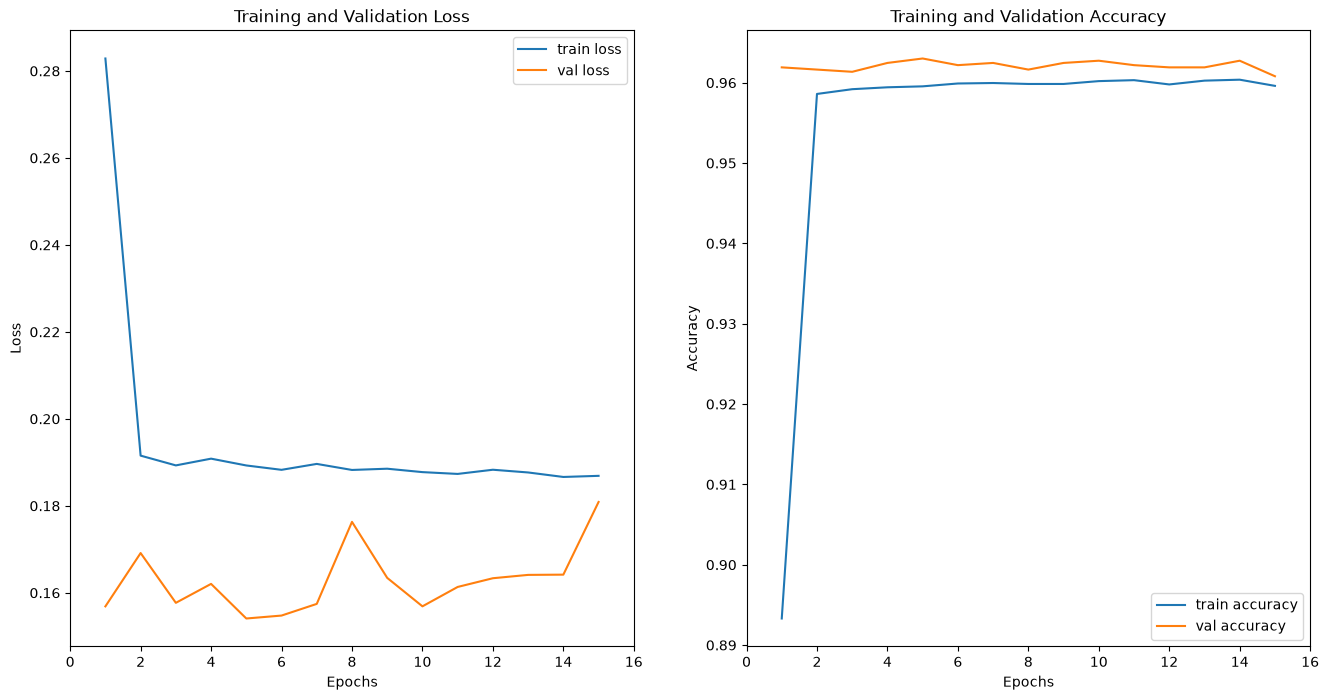

In [104]:
# plot the training and validation loss and accuracy
history_combined = pd.read_csv(os.path.join(path, 'training_cnn_with_physics.log'))

plt.figure(figsize=(16, 8))
# Loss Subplot
plt.subplot(1, 2, 1)
plt.plot(history_combined['epoch'] + 1, history_combined['loss'], label='train loss')
plt.plot(history_combined['epoch'] + 1, history_combined['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.xlim(0, len(history_combined['epoch']) + 1)
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy Subplot
plt.subplot(1, 2, 2)
plt.plot(history_combined['epoch'] + 1, history_combined['accuracy'], label='train accuracy')
plt.plot(history_combined['epoch'] + 1, history_combined['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.xlim(0, len(history_combined['epoch']) + 1)
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

In [105]:
# Evaluate the model on the test data
test_loss, test_accuracy = model_combined.evaluate([data_test, tail_to_total_test], labels_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1823, Test Accuracy: 0.9630


114/114 [==============================] - 0s 2ms/step


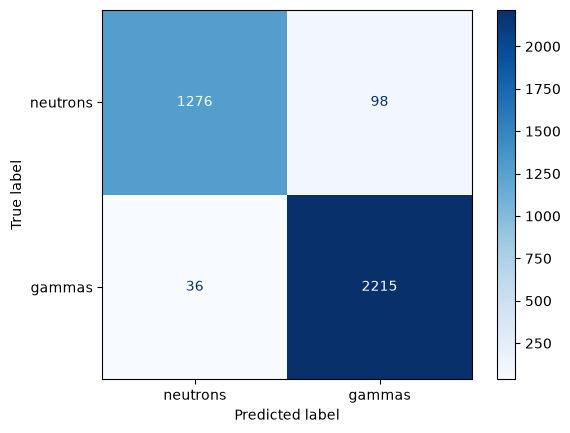

In [106]:
# plot confusion matrix for the combined model
predictions_combined = model_combined.predict([data_test, tail_to_total_test])
cm_combined = confusion_matrix(labels_test, predictions_combined.argmax(axis=1))

disp_combined = ConfusionMatrixDisplay(confusion_matrix=cm_combined, display_labels=['neutrons', 'gammas'])
disp_combined.plot(cmap=plt.cm.Blues)

I tried to improve the network through different means. Changing the architecture, the data preprocessing and including more 'physics' information explicitly for the network.
The change in preprocessing to put the peak always in the same index improved the network measurably and reduced the number of misidentified neutrons by about 30% for the improved cnn.
Including the tail-to-total area fraction with a different network architecture did not further improve the result.

## 4

Since train val and test all come from the same source and are just split at the beginning, the network should be as reliable on the test as on the validation. Because the test dataset was generated using the exact same flawed TOF method as the training dataset, the test set inherits the exact same biases. Therefore, it is a reliable metric of the model's predictive power against the labels, but it is an unreliable metric of the model's predictive power against physical reality.

The true accuracy is different. The model is being penalized for being better than the label selection.
Two physical phenomena that get completely ignored by the way we chose the labels are reflecting gamma and gamma pileup in the detector. A reflected gamma can have the same TOF as a neutron and would be labeled as a neutron.
If two gammas reach the detector at basically the same time, the merged pulse is wider and physically looks more similar to a neutron. The TOF will show its a gamma but for the network it will look like a neutron because of its pulse shape.

The true accuracy is likely higher, as the model seemingly mostly struggles with wrong labels. If there was a way to reliably get the labels through accessing the physical ground thruth the model could be even better.